In [1]:
import numpy as np
import pandas as pd
data = np.load("../data/processed/FULL_30.npz", allow_pickle=True)
X_full = data["X"]

train = np.load("../data/processed/TRAIN_30.npz", allow_pickle=True)

X_train = train["X"]
y_train = train["y"]

df = pd.DataFrame(X_full, columns=[f"F{i}" for i in range(1,31)])


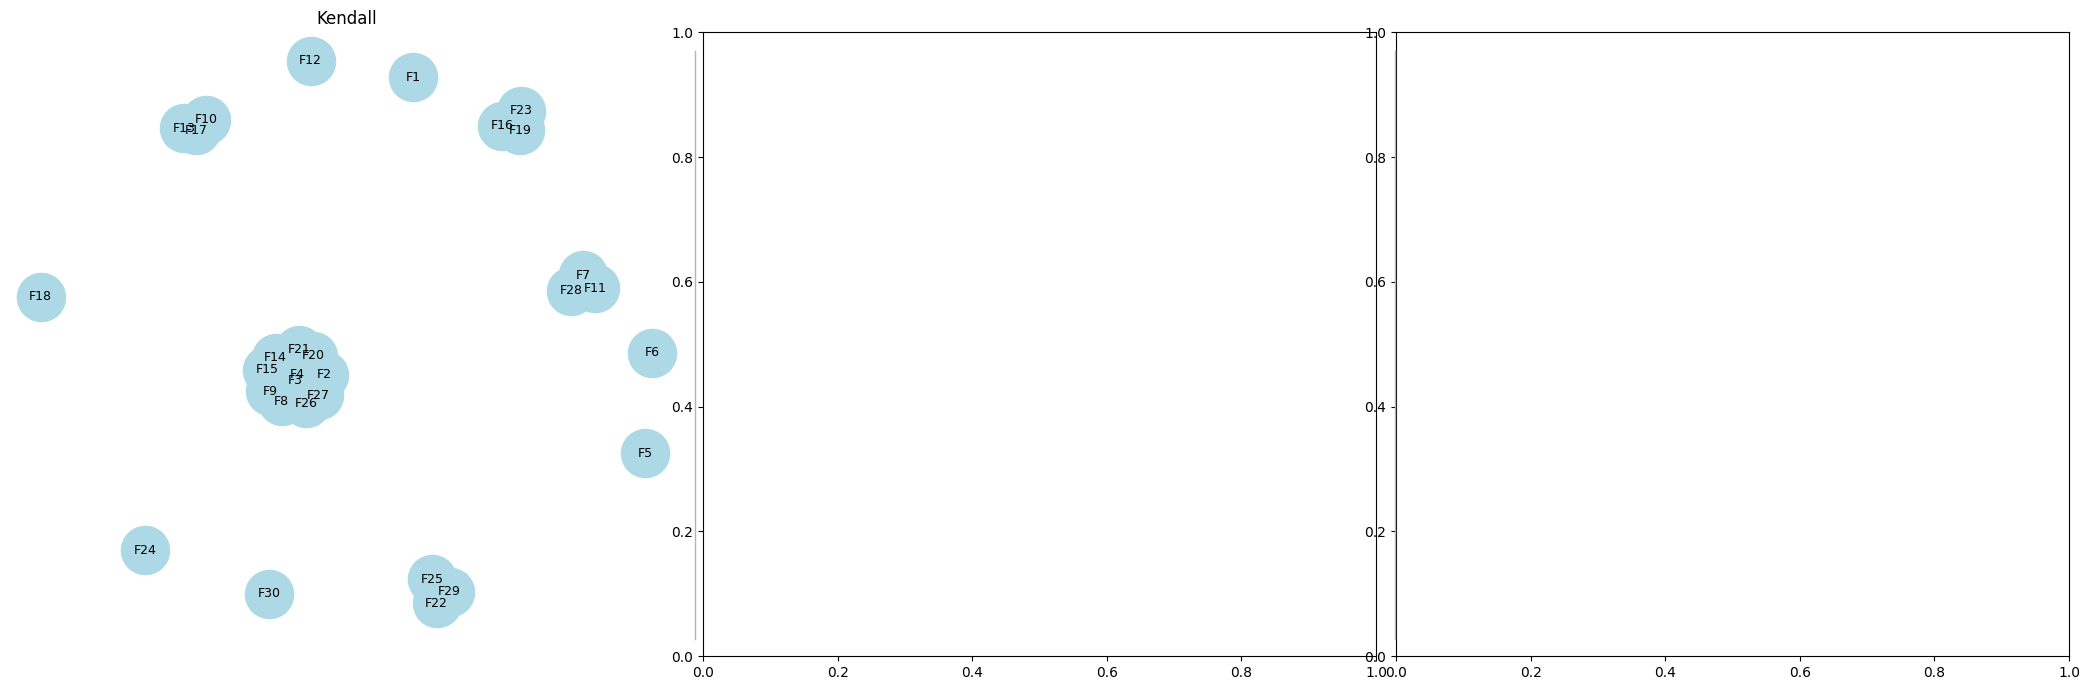

In [2]:
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import networkx as nx

corr_methods = {
    # "Pearson": df.corr().abs(),
    # "Spearman": df.corr(method="spearman").abs(),
    "Kendall": df.corr(method="kendall").abs()
}

threshold = 0.8

fig, axes = plt.subplots(1, 3, figsize=(21, 7))

for ax, (name, corr) in zip(axes, corr_methods.items()):
    G = nx.Graph()

    for col in df.columns:
        G.add_node(col)

    for i in range(len(df.columns)):
        for j in range(i + 1, len(df.columns)):
            if corr.iloc[i, j] > threshold:
                G.add_edge(
                    df.columns[i],
                    df.columns[j],
                    weight=corr.iloc[i, j]
                )

    pos = nx.spring_layout(G, seed=0)

    weights = [d["weight"] * 3 for _, _, d in G.edges(data=True)]

    nx.draw(
        G,
        pos,
        ax=ax,
        with_labels=True,
        width=weights,
        node_size=1200,
        node_color="lightblue",
        font_size=9,
    )

    ax.set_title(name)


plt.tight_layout()
fig.subplots_adjust(wspace=0.03)

for x in [1/3, 2/3]:
    fig.add_artist(
        Line2D(
            [x, x],
            [0.08, 0.92],
            transform=fig.transFigure,
            color="0.7",
            linewidth=1
        )
    )
plt.savefig(
    "feature_correlation_graphs.png",
    dpi=300,
)

plt.show()

In [3]:
plt.savefig(
    "feature_correlation_graphs.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

In [4]:
groups = []
for comp in nx.connected_components(G):
    if len(comp) > 1:
        groups.append(comp)
        print(sorted(comp))

['F14', 'F15', 'F2', 'F20', 'F21', 'F26', 'F27', 'F3', 'F4', 'F8', 'F9']
['F11', 'F28', 'F7']
['F10', 'F13', 'F17']
['F16', 'F19', 'F23']
['F22', 'F25', 'F29']


In [5]:
from sklearn.decomposition import PCA

pca = PCA(n_components=1)
group1 = sorted(groups[0])

group1_pc = pca.fit_transform(df[group1])

In [6]:

for i, group in enumerate(groups):
    cols = list(group)

    pca = PCA(n_components=1)
    pca.fit(df[cols])

    print(
        f"Group {i+1}: "
        f"{len(cols)} features -> "
        f"PC1 explains {pca.explained_variance_ratio_[0]:.3f}"
    )

Group 1: 11 features -> PC1 explains 0.998
Group 2: 3 features -> PC1 explains 1.000
Group 3: 3 features -> PC1 explains 1.000
Group 4: 3 features -> PC1 explains 1.000
Group 5: 3 features -> PC1 explains 1.000


In [7]:
for i, group in enumerate(groups):
    pca = PCA(n_components=1)
    pca.fit(df[list(group)])

    print(
        f"Group {i+1}: "
        f"{pca.explained_variance_ratio_[0]:.10f}"
    )

Group 1: 0.9977904290
Group 2: 0.9999985629
Group 3: 0.9999985633
Group 4: 0.9999985676
Group 5: 0.9999985562


In [8]:
for group in groups:

    group_list = list(group) 
    
    pca = PCA(n_components=1)
    pca.fit(df[group_list])
    
    loadings = pd.Series(
        np.abs(pca.components_[0]),
        index=group
    ).sort_values(ascending=False)
    
    print(loadings)

F3     0.862764
F4     0.431321
F2     0.215845
F14    0.053737
F15    0.053687
F20    0.053679
F21    0.053645
F26    0.053620
F9     0.053604
F27    0.053554
F8     0.053532
dtype: float64
F7     0.688837
F28    0.688837
F11    0.225846
dtype: float64
F10    0.688837
F13    0.688837
F17    0.225845
dtype: float64
F16    0.688837
F19    0.688837
F23    0.225848
dtype: float64
F22    0.688838
F25    0.688838
F29    0.225844
dtype: float64


In [9]:
representatives = []

for group in groups:
    group_list = list(group)

    pca = PCA(n_components=1)
    pca.fit(df[group_list])

    loadings = pd.Series(
        np.abs(pca.components_[0]),
        index=group_list
    )

    representative = loadings.idxmax()
    representatives.append(representative)

    print(f"Group: {sorted(group_list)}")
    print(f"Representative: {representative}")

Group: ['F14', 'F15', 'F2', 'F20', 'F21', 'F26', 'F27', 'F3', 'F4', 'F8', 'F9']
Representative: F3
Group: ['F11', 'F28', 'F7']
Representative: F7
Group: ['F10', 'F13', 'F17']
Representative: F10
Group: ['F16', 'F19', 'F23']
Representative: F16
Group: ['F22', 'F25', 'F29']
Representative: F22


In [10]:
representatives = []

for group in groups:
    cols = list(group)

    corr = df[cols].corr().abs()

    mean_corr = corr.mean(axis=1)

    rep = mean_corr.idxmax()

    representatives.append(rep)

    print(f"Group: {sorted(cols)}")
    print(f"Representative: {rep}")
    print()

Group: ['F14', 'F15', 'F2', 'F20', 'F21', 'F26', 'F27', 'F3', 'F4', 'F8', 'F9']
Representative: F4

Group: ['F11', 'F28', 'F7']
Representative: F28

Group: ['F10', 'F13', 'F17']
Representative: F13

Group: ['F16', 'F19', 'F23']
Representative: F19

Group: ['F22', 'F25', 'F29']
Representative: F25



In [11]:
from sklearn.decomposition import PCA

representatives = []

for group in groups:
    cols = list(group)

    pca = PCA(n_components=1)
    pc1 = pca.fit_transform(df[cols]).ravel()

    corr_with_pc1 = {
        col: abs(np.corrcoef(df[col], pc1)[0,1])
        for col in cols
    }

    rep = max(corr_with_pc1, key=corr_with_pc1.get)

    representatives.append(rep)

    print(rep)

F3
F28
F13
F19
F25


In [12]:
grouped_features = set().union(*groups)

isolated = [
    col for col in df.columns
    if col not in grouped_features
]

selected_features = representatives + isolated

print(selected_features)
print(len(selected_features))

['F3', 'F28', 'F13', 'F19', 'F25', 'F1', 'F5', 'F6', 'F12', 'F18', 'F24', 'F30']
12


/tmp/ipykernel_18934/1640235116.py:374: UserWarning: 

The connectionstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(


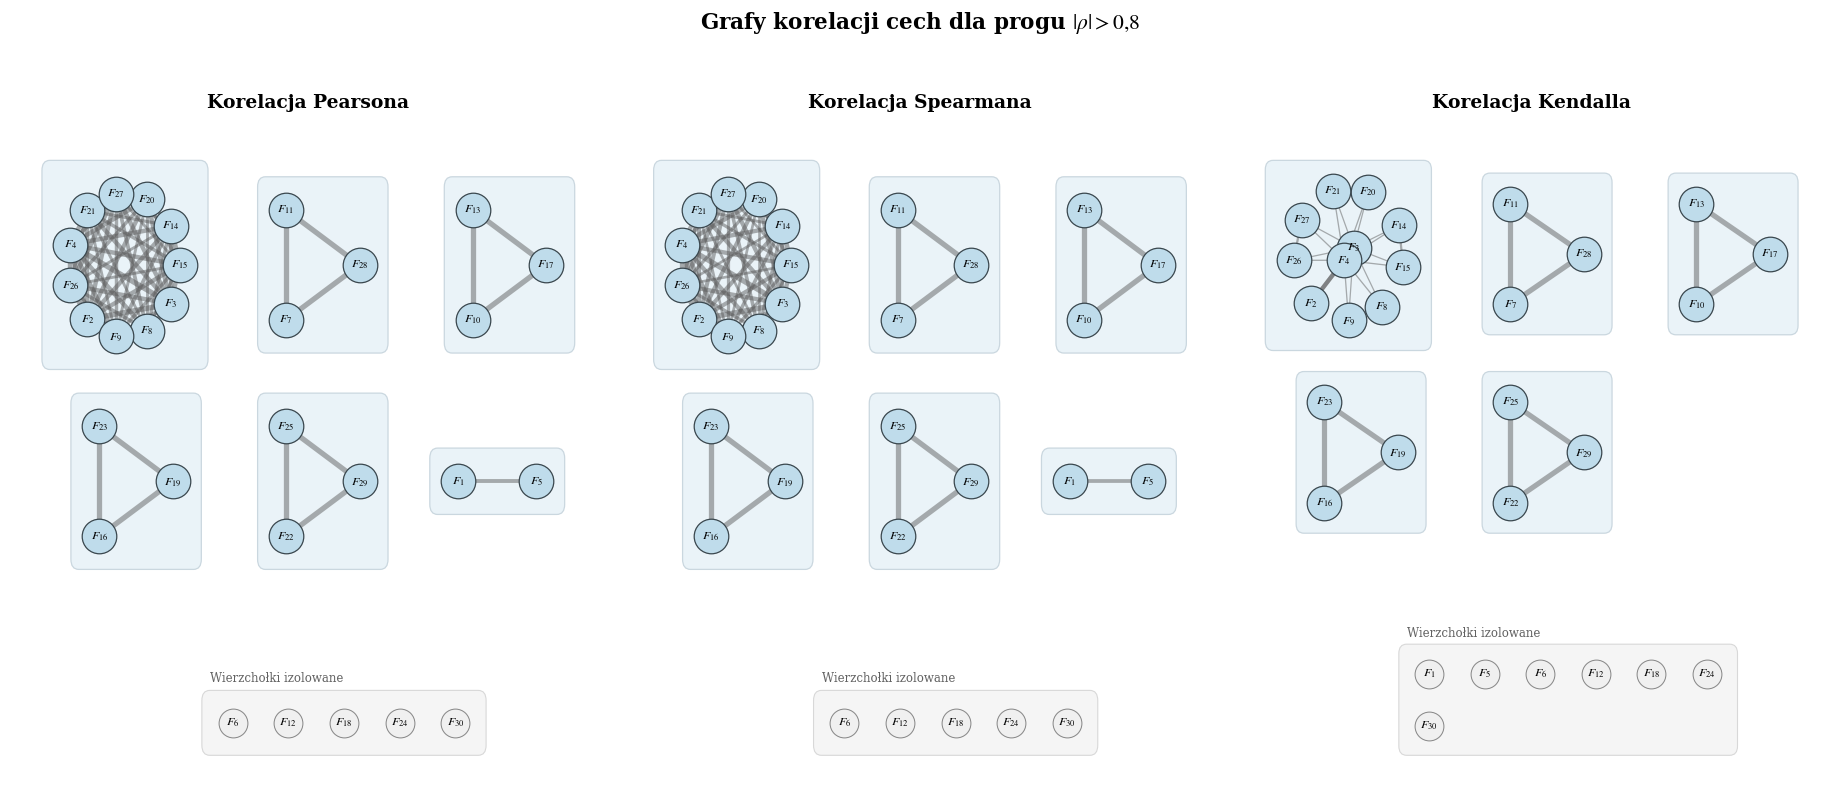


Grupy dla korelacji Kendalla:
Grupa 1: ['F2', 'F3', 'F4', 'F8', 'F9', 'F14', 'F15', 'F20', 'F21', 'F26', 'F27']
Grupa 2: ['F7', 'F11', 'F28']
Grupa 3: ['F10', 'F13', 'F17']
Grupa 4: ['F16', 'F19', 'F23']
Grupa 5: ['F22', 'F25', 'F29']


In [13]:
import re
import math
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from matplotlib.patches import FancyBboxPatch


# ============================================================
# USTAWIENIA
# ============================================================

THRESHOLD = 0.8

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "stix",
    "font.size": 10,
})


# ============================================================
# POMOCNICZE
# ============================================================

def feature_number(name):
    """
    F1 -> 1
    F12 -> 12
    """
    match = re.search(r"(\d+)$", str(name))

    if match:
        return int(match.group(1))

    return 10**9


def build_graph(corr, threshold=0.8):
    """
    Buduje graf korelacji.
    Wierzchołki = cechy.
    Krawędź istnieje dla |rho| > threshold.
    """

    G = nx.Graph()

    columns = list(corr.columns)

    G.add_nodes_from(columns)

    for i in range(len(columns)):
        for j in range(i + 1, len(columns)):

            weight = float(corr.iloc[i, j])

            if weight > threshold:
                G.add_edge(
                    columns[i],
                    columns[j],
                    weight=weight
                )

    return G


# ============================================================
# UKŁAD SPÓJNYCH SKŁADOWYCH
# ============================================================

def component_layout(G):

    # składowe zawierające co najmniej 2 cechy
    components = [
        sorted(component, key=feature_number)
        for component in nx.connected_components(G)
        if len(component) > 1
    ]

    # największe najpierw
    components.sort(
        key=lambda c: (
            -len(c),
            feature_number(c[0])
        )
    )

    # wierzchołki izolowane
    isolates = sorted(
        nx.isolates(G),
        key=feature_number
    )

    n_components = len(components)

    # liczba kolumn z grupami
    ncols = min(
        3,
        max(
            1,
            math.ceil(
                math.sqrt(max(n_components, 1))
            )
        )
    )

    nrows = max(
        1,
        math.ceil(
            max(n_components, 1) / ncols
        )
    )

    cell_width = 3.35
    cell_height = 3.0

    pos = {}

    component_boxes = []


    # --------------------------------------------------------
    # rozmieszczenie każdej spójnej składowej osobno
    # --------------------------------------------------------

    for idx, nodes in enumerate(components):

        row, col = divmod(idx, ncols)

        center_x = col * cell_width
        center_y = -row * cell_height

        H = G.subgraph(nodes)


        # 2 wierzchołki -> po prostu poziomo
        if len(nodes) == 2:

            local_pos = {
                nodes[0]: (-0.70, 0.0),
                nodes[1]: ( 0.70, 0.0),
            }


        # małe grupy -> koło
        elif len(nodes) <= 6:

            local_pos = nx.circular_layout(
                H,
                scale=0.88
            )


        # większe grupy -> Kamada-Kawai
        else:

            local_pos = nx.kamada_kawai_layout(
                H,
                weight=None,
                scale=1.0
            )


        # przesunięcie składowej do jej komórki
        for node, xy in local_pos.items():

            pos[node] = (
                center_x + float(xy[0]),
                center_y + float(xy[1])
            )


        # prostokąt otaczający grupę
        xs = [pos[node][0] for node in nodes]
        ys = [pos[node][1] for node in nodes]

        padding_x = 0.48
        padding_y = 0.43

        component_boxes.append(
            (
                min(xs) - padding_x,
                min(ys) - padding_y,

                max(xs) - min(xs) + 2 * padding_x,
                max(ys) - min(ys) + 2 * padding_y,
            )
        )


    # ========================================================
    # WIERZCHOŁKI IZOLOWANE
    # ========================================================

    isolated_box = None

    if isolates:

        # maksymalnie 6 w jednym wierszu
        iso_cols = min(
            6,
            len(isolates)
        )

        iso_rows = math.ceil(
            len(isolates) / iso_cols
        )

        dx = 1.0
        dy = 0.78

        graph_width = max(
            (ncols - 1) * cell_width + 2.2,
            (iso_cols - 1) * dx + 1.0
        )

        x_start = (
            graph_width
            - (iso_cols - 1) * dx
        ) / 2 - 0.5

        y_start = (
            -nrows * cell_height
            - 0.35
        )


        for idx, node in enumerate(isolates):

            row, col = divmod(
                idx,
                iso_cols
            )

            pos[node] = (
                x_start + col * dx,
                y_start - row * dy
            )


        xs = [pos[node][0] for node in isolates]
        ys = [pos[node][1] for node in isolates]

        isolated_box = (
            min(xs) - 0.52,
            min(ys) - 0.42,

            max(xs) - min(xs) + 1.04,
            max(ys) - min(ys) + 0.84,
        )


    return (
        pos,
        components,
        isolates,
        component_boxes,
        isolated_box,
    )


# ============================================================
# RYSOWANIE POJEDYNCZEGO GRAFU
# ============================================================

def draw_corr_graph(
    ax,
    G,
    title,
    threshold=0.8
):

    (
        pos,
        components,
        isolates,
        component_boxes,
        isolated_box,
    ) = component_layout(G)


    # --------------------------------------------------------
    # tła spójnych składowych
    # --------------------------------------------------------

    for x, y, width, height in component_boxes:

        box = FancyBboxPatch(
            (x, y),
            width,
            height,

            boxstyle=(
                "round,"
                "pad=0.03,"
                "rounding_size=0.14"
            ),

            facecolor="#EAF3F8",
            edgecolor="#CAD7DF",

            linewidth=0.9,
            zorder=0
        )

        ax.add_patch(box)


    # --------------------------------------------------------
    # tło wierzchołków izolowanych
    # --------------------------------------------------------

    if isolated_box is not None:

        x, y, width, height = isolated_box

        box = FancyBboxPatch(
            (x, y),
            width,
            height,

            boxstyle=(
                "round,"
                "pad=0.03,"
                "rounding_size=0.14"
            ),

            facecolor="#F5F5F5",
            edgecolor="#D8D8D8",

            linewidth=0.8,
            zorder=0
        )

        ax.add_patch(box)

        ax.text(
            x + 0.12,
            y + height + 0.10,

            "Wierzchołki izolowane",

            fontsize=8.5,
            color="0.38",

            ha="left",
            va="bottom"
        )


    # ========================================================
    # KRAWĘDZIE
    # ========================================================

    edges = list(
        G.edges(data=True)
    )

    if edges:

        # 0.8 -> cienka
        # 1.0 -> gruba
        widths = [
            0.8
            + 3.0
            * (
                (data["weight"] - threshold)
                / (1.0 - threshold)
            )
            for _, _, data in edges
        ]

        nx.draw_networkx_edges(
            G,
            pos,

            ax=ax,

            edgelist=[
                (u, v)
                for u, v, _ in edges
            ],

            width=widths,

            edge_color="0.35",

            alpha=0.48,

            connectionstyle="arc3,rad=0.02"
        )


    # ========================================================
    # WIERZCHOŁKI
    # ========================================================

    connected_nodes = [
        node
        for node in G.nodes
        if G.degree(node) > 0
    ]


    if connected_nodes:

        nx.draw_networkx_nodes(
            G,
            pos,

            ax=ax,

            nodelist=connected_nodes,

            node_size=620,

            node_color="#BFDCEB",

            edgecolors="#39464D",

            linewidths=0.9
        )


    # izolowane trochę mniejsze i szare
    if isolates:

        nx.draw_networkx_nodes(
            G,
            pos,

            ax=ax,

            nodelist=isolates,

            node_size=430,

            node_color="#F0F0F0",

            edgecolors="#8A8A8A",

            linewidths=0.75
        )


    # ========================================================
    # ETYKIETY F_i
    # ========================================================

    labels = {}

    for node in G.nodes:

        number = feature_number(node)

        if number < 10**9:
            labels[node] = rf"$F_{{{number}}}$"
        else:
            labels[node] = str(node)


    nx.draw_networkx_labels(
        G,
        pos,

        labels=labels,

        ax=ax,

        font_size=8.8,

        font_weight="medium"
    )


    # ========================================================
    # TYTUŁ
    # ========================================================

    ax.set_title(
        title,

        fontsize=13.5,

        fontweight="bold",

        pad=12
    )

    ax.set_axis_off()

    ax.margins(0.06)


# ============================================================
# MACIERZE KORELACJI
# ============================================================

corr_methods = {

    "Korelacja Pearsona":
        df.corr().abs(),

    "Korelacja Spearmana":
        df.corr(method="spearman").abs(),

    "Korelacja Kendalla":
        df.corr(method="kendall").abs(),
}


# ============================================================
# GRAFY
# ============================================================

graphs = {
    name: build_graph(
        corr,
        threshold=THRESHOLD
    )
    for name, corr in corr_methods.items()
}


# ============================================================
# RYSUNEK
# ============================================================

fig, axes = plt.subplots(
    1,
    3,

    figsize=(18.5, 8.0)
)


for ax, (name, G_plot) in zip(
    axes,
    graphs.items()
):

    draw_corr_graph(
        ax,
        G_plot,
        name,
        threshold=THRESHOLD
    )


fig.suptitle(
    r"Grafy korelacji cech dla progu $|\rho| > 0{,}8$",

    fontsize=15.5,

    fontweight="bold",

    y=0.995
)


plt.tight_layout(
    rect=[0, 0, 1, 0.96]
)


# ============================================================
# ZAPIS
# ============================================================

plt.savefig(
    "feature_correlation_graphs_pretty.pdf",

    bbox_inches="tight"
)

plt.savefig(
    "feature_correlation_graphs_pretty.png",

    dpi=300,

    bbox_inches="tight"
)

plt.show()


# ============================================================
# WAŻNE:
# zachowujemy G i groups dla dalszych komórek notebooka
# Tak jak wcześniej korzystasz z nich przy PCA.
# ============================================================

G = graphs["Korelacja Kendalla"]

groups = [
    component
    for component in nx.connected_components(G)
    if len(component) > 1
]


groups = sorted(
    groups,
    key=lambda group: (
        -len(group),
        min(feature_number(x) for x in group)
    )
)


print("\nGrupy dla korelacji Kendalla:")

for i, group in enumerate(groups, start=1):

    print(
        f"Grupa {i}:",
        sorted(
            group,
            key=feature_number
        )
    )

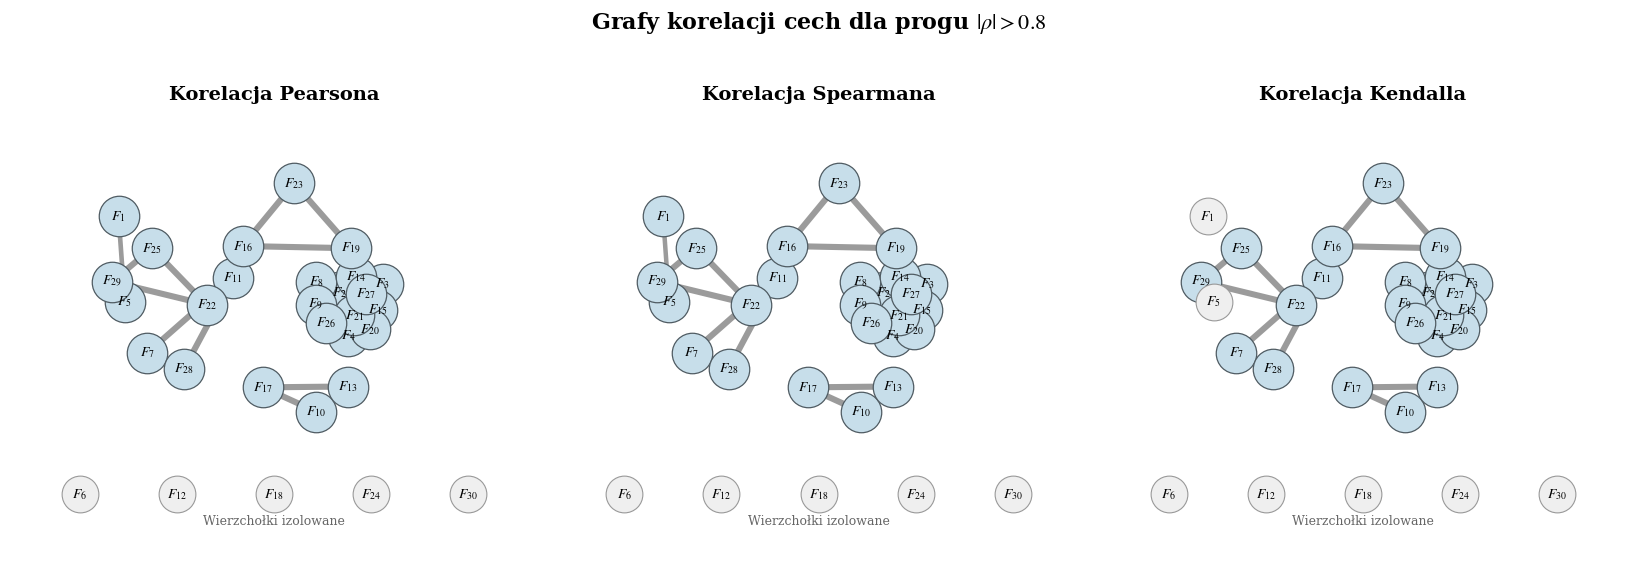

In [14]:
import re
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# =========================================
# USTAWIENIA
# =========================================

threshold = 0.8

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "stix",
    "font.size": 11,
})

# =========================================
# FUNKCJE POMOCNICZE
# =========================================

def feature_num(label):
    m = re.search(r"(\d+)$", str(label))
    return int(m.group(1)) if m else 10**9


def pretty_label(label):
    n = feature_num(label)
    if n < 10**9:
        return rf"$F_{{{n}}}$"
    return str(label)


def build_graph(corr, columns, threshold=0.8):
    G = nx.Graph()
    G.add_nodes_from(columns)

    for i in range(len(columns)):
        for j in range(i + 1, len(columns)):
            w = float(corr.iloc[i, j])
            if w > threshold:
                G.add_edge(columns[i], columns[j], weight=w)

    return G


def shared_layout(graphs):
    """
    Jeden wspólny układ dla wszystkich metod,
    żeby Pearson/Spearman/Kendall były porównywalne.
    """
    U = nx.Graph()

    for G in graphs.values():
        U.add_nodes_from(G.nodes())
        U.add_edges_from(G.edges())

    if U.number_of_edges() > 0:
        pos = nx.spring_layout(U, seed=7, k=0.9)
    else:
        pos = {n: np.array([0.0, 0.0]) for n in U.nodes()}

    isolates = sorted(nx.isolates(U), key=feature_num)
    non_isolates = [n for n in U.nodes() if n not in isolates]

    if isolates:
        if non_isolates:
            ymin = min(pos[n][1] for n in non_isolates)
        else:
            ymin = 0.0

        xs = np.linspace(-1.2, 1.2, len(isolates))
        y = ymin - 0.55

        for x, n in zip(xs, isolates):
            pos[n] = np.array([x, y])

    return pos, isolates


def draw_graph(ax, G, pos, isolates, title, threshold=0.8):
    connected_nodes = [n for n in G.nodes() if G.degree(n) > 0]
    local_isolates = [n for n in G.nodes() if G.degree(n) == 0]

    # krawędzie
    edges = list(G.edges(data=True))
    if edges:
        widths = [
            1.2 + 3.2 * ((d["weight"] - threshold) / (1.0 - threshold))
            for _, _, d in edges
        ]

        nx.draw_networkx_edges(
            G,
            pos,
            ax=ax,
            edgelist=[(u, v) for u, v, _ in edges],
            width=widths,
            edge_color="#7a7a7a",
            alpha=0.75
        )

    # wierzchołki połączone
    if connected_nodes:
        nx.draw_networkx_nodes(
            G,
            pos,
            ax=ax,
            nodelist=connected_nodes,
            node_size=850,
            node_color="#c7deea",
            edgecolors="#4f5b62",
            linewidths=0.9
        )

    # wierzchołki izolowane
    if local_isolates:
        nx.draw_networkx_nodes(
            G,
            pos,
            ax=ax,
            nodelist=local_isolates,
            node_size=700,
            node_color="#efefef",
            edgecolors="#999999",
            linewidths=0.8
        )

    # etykiety
    labels = {n: pretty_label(n) for n in G.nodes()}
    nx.draw_networkx_labels(
        G,
        pos,
        labels=labels,
        ax=ax,
        font_size=10
    )

    # podpis izolowanych
    if local_isolates:
        iso_y = min(pos[n][1] for n in local_isolates)
        ax.text(
            0.0,
            iso_y - 0.14,
            "Wierzchołki izolowane",
            ha="center",
            va="top",
            fontsize=9,
            color="0.4"
        )

    ax.set_title(title, fontsize=14, fontweight="bold", pad=10)
    ax.set_axis_off()
    ax.margins(0.18)


# =========================================
# MACIERZE KORELACJI
# =========================================

corr_methods = {
    "Korelacja Pearsona": df.corr().abs(),
    "Korelacja Spearmana": df.corr(method="spearman").abs(),
    "Korelacja Kendalla": df.corr(method="kendall").abs(),
}

columns = list(df.columns)

graphs = {
    name: build_graph(corr, columns, threshold=threshold)
    for name, corr in corr_methods.items()
}

# wspólny układ
pos, isolates = shared_layout(graphs)

# =========================================
# RYSUNEK
# =========================================

fig, axes = plt.subplots(1, 3, figsize=(16.5, 5.7))

for ax, (name, G) in zip(axes, graphs.items()):
    draw_graph(ax, G, pos, isolates, name, threshold=threshold)

fig.suptitle(
    r"Grafy korelacji cech dla progu $|\rho| > 0.8$",
    fontsize=16,
    fontweight="bold",
    y=0.98
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig("feature_correlation_graphs_clean.png", dpi=300, bbox_inches="tight")
plt.savefig("feature_correlation_graphs_clean.pdf", bbox_inches="tight")
plt.show()

In [16]:
import re
import math
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from matplotlib.patches import Circle

# ============================================================
# USTAWIENIA
# ============================================================

THRESHOLD = 0.8
METHOD = "kendall"   # "pearson", "spearman", "kendall"

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "stix",
    "font.size": 12,
})


# ============================================================
# POMOCNICZE
# ============================================================

def feature_num(name):
    m = re.search(r"(\d+)$", str(name))
    return int(m.group(1)) if m else 10**9


def pretty_label(name):
    n = feature_num(name)
    if n < 10**9:
        return rf"$F_{{{n}}}$"
    return str(name)


def build_graph(df, method="kendall", threshold=0.8):
    corr = df.corr(method=method).abs()

    G = nx.Graph()
    cols = list(df.columns)
    G.add_nodes_from(cols)

    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            w = float(corr.iloc[i, j])
            if w > threshold:
                G.add_edge(cols[i], cols[j], weight=w)

    return G, corr


def component_positions(G):
    """
    Układ:
    - największa składowa w środku,
    - pozostałe składowe wokół,
    - izolowane wierzchołki na zewnętrznym pierścieniu.
    """
    components = list(nx.connected_components(G))
    components = [sorted(list(c), key=feature_num) for c in components]

    big_components = [c for c in components if len(c) > 1]
    isolates = [c[0] for c in components if len(c) == 1]

    big_components.sort(key=lambda c: (-len(c), feature_num(c[0])))
    isolates = sorted(isolates, key=feature_num)

    pos = {}

    # --------------------------------------------------------
    # 1. Największa grupa w środku
    # --------------------------------------------------------
    if big_components:
        main = big_components[0]
        H = G.subgraph(main)

        if len(main) <= 3:
            local = nx.circular_layout(H, scale=0.22)
        else:
            local = nx.spring_layout(H, seed=4, k=0.45)

            # normalizacja rozmiaru
            arr = np.array(list(local.values()))
            arr = arr - arr.mean(axis=0)
            max_norm = np.max(np.linalg.norm(arr, axis=1))
            if max_norm > 0:
                arr = arr / max_norm * 0.28
            local = {node: arr[i] for i, node in enumerate(H.nodes())}

        for node in H.nodes():
            pos[node] = np.array(local[node])

    # --------------------------------------------------------
    # 2. Mniejsze grupy wokół środka
    # --------------------------------------------------------
    satellites = big_components[1:]
    n_sat = len(satellites)

    if n_sat > 0:
        angles = np.linspace(0, 2*np.pi, n_sat, endpoint=False)
        R = 0.82

        for comp, angle in zip(satellites, angles):
            cx = R * np.cos(angle)
            cy = R * np.sin(angle)

            H = G.subgraph(comp)

            if len(comp) == 2:
                local = {
                    comp[0]: np.array([-0.08,  0.00]),
                    comp[1]: np.array([ 0.08,  0.00]),
                }

            elif len(comp) == 3:
                local = nx.circular_layout(H, scale=0.11)

            else:
                local = nx.spring_layout(H, seed=4, k=0.35)
                arr = np.array(list(local.values()))
                arr = arr - arr.mean(axis=0)
                max_norm = np.max(np.linalg.norm(arr, axis=1))
                if max_norm > 0:
                    arr = arr / max_norm * 0.14
                local = {node: arr[i] for i, node in enumerate(H.nodes())}

            for node in H.nodes():
                pos[node] = np.array([cx, cy]) + np.array(local[node])

    # --------------------------------------------------------
    # 3. Izolowane wierzchołki na zewnątrz
    # --------------------------------------------------------
    if isolates:
        n_iso = len(isolates)
        angles = np.linspace(0, 2*np.pi, n_iso, endpoint=False) + np.pi / 10
        R_iso = 1.28

        for node, angle in zip(isolates, angles):
            pos[node] = np.array([
                R_iso * np.cos(angle),
                R_iso * np.sin(angle)
            ])

    return pos, big_components, isolates


def component_radius(component, pos, extra=0.12):
    pts = np.array([pos[n] for n in component])
    center = pts.mean(axis=0)
    d = np.linalg.norm(pts - center, axis=1).max()
    return center, d + extra


# ============================================================
# RYSOWANIE
# ============================================================

def draw_corr_graph_pretty(df, method="kendall", threshold=0.8,
                           output_png="corr_graph_pretty.png",
                           output_pdf="corr_graph_pretty.pdf"):

    G, corr = build_graph(df, method=method, threshold=threshold)
    pos, big_components, isolates = component_positions(G)

    fig, ax = plt.subplots(figsize=(8.8, 8.2))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    # pastelowa paleta dla grup
    palette = [
        "#A8D8EA",  # pastel blue
        "#F7C8A9",  # pastel peach
        "#C7E9B4",  # pastel green
        "#D4C1EC",  # pastel violet
        "#F6D6E6",  # pastel pink
        "#F9E79F",  # pastel yellow
        "#AED9CE",  # mint
        "#C9DAF8",  # light periwinkle
    ]

    # --------------------------------------------------------
    # delikatne overlaye grup
    # --------------------------------------------------------
    for i, comp in enumerate(big_components):
        color = palette[i % len(palette)]
        center, radius = component_radius(comp, pos, extra=0.14 if len(comp) > 4 else 0.10)

        halo = Circle(
            center,
            radius=radius,
            facecolor=color,
            edgecolor="none",
            alpha=0.18,
            zorder=0
        )
        ax.add_patch(halo)

    # --------------------------------------------------------
    # krawędzie
    # --------------------------------------------------------
    edges = list(G.edges(data=True))
    if edges:
        widths = [
            1.2 + 3.5 * (d["weight"] - threshold) / (1.0 - threshold)
            for _, _, d in edges
        ]

        nx.draw_networkx_edges(
            G,
            pos,
            ax=ax,
            width=widths,
            edge_color="#7A7A7A",
            alpha=0.55
        )

    # --------------------------------------------------------
    # wierzchołki - kolor wg grup
    # --------------------------------------------------------
    node_colors = {}
    for i, comp in enumerate(big_components):
        color = palette[i % len(palette)]
        for n in comp:
            node_colors[n] = color

    for n in isolates:
        node_colors[n] = "#E8EEF2"

    nx.draw_networkx_nodes(
        G,
        pos,
        ax=ax,
        node_size=1350,
        node_color=[node_colors[n] for n in G.nodes()],
        edgecolors="#5F6B73",
        linewidths=1.0
    )

    # --------------------------------------------------------
    # etykiety
    # --------------------------------------------------------
    labels = {n: pretty_label(n) for n in G.nodes()}
    nx.draw_networkx_labels(
        G,
        pos,
        labels=labels,
        ax=ax,
        font_size=12
    )

    # --------------------------------------------------------
    # tytuł
    # --------------------------------------------------------
    method_title = {
        "pearson": "Pearson",
        "spearman": "Spearman",
        "kendall": "Kendall"
    }.get(method.lower(), method.capitalize())

    ax.set_title(
        rf"Graf korelacji cech ({method_title}, $|\rho| > {threshold}$)",
        fontsize=16,
        fontweight="bold",
        pad=16
    )

    ax.set_axis_off()
    ax.set_aspect("equal")

    plt.tight_layout()

    plt.savefig(output_png, dpi=300, bbox_inches="tight")
    plt.savefig(output_pdf, bbox_inches="tight")
    plt.show()

    return G, corr, pos

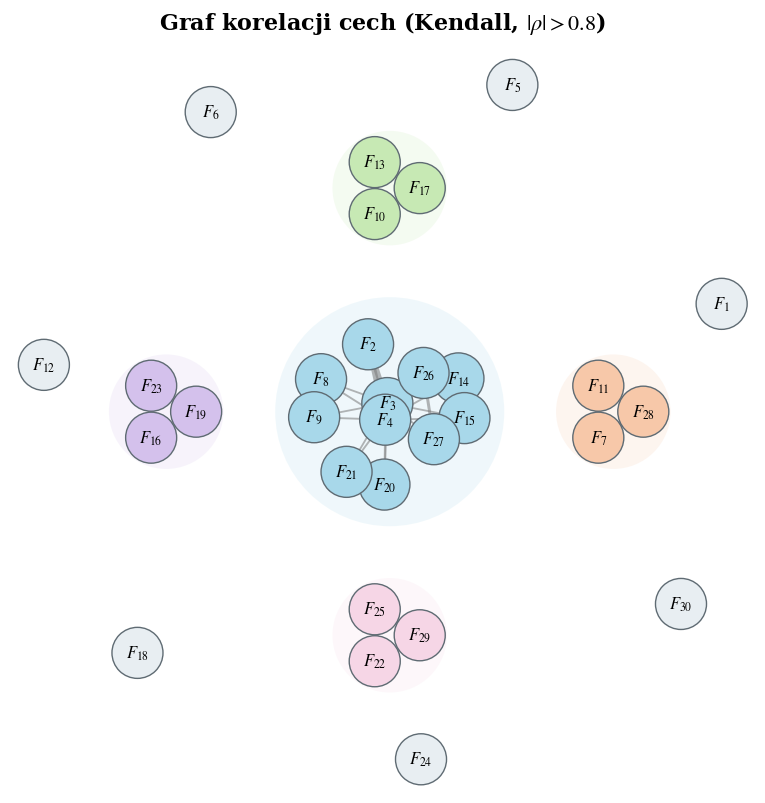

In [17]:
G, corr, pos = draw_corr_graph_pretty(
    df,
    method="kendall",
    threshold=0.8,
    output_png="kendall_corr_pretty.png",
    output_pdf="kendall_corr_pretty.pdf"
)

In [18]:
import re
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from matplotlib.patches import Ellipse

# ============================================================
# USTAWIENIA
# ============================================================

THRESHOLD = 0.8
METHOD = "kendall"   # "pearson", "spearman", "kendall"

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "stix",
    "font.size": 12,
})


# ============================================================
# POMOCNICZE
# ============================================================

def feature_num(name):
    m = re.search(r"(\d+)$", str(name))
    return int(m.group(1)) if m else 10**9


def pretty_label(name):
    n = feature_num(name)
    if n < 10**9:
        return rf"$F_{{{n}}}$"
    return str(name)


def build_graph(df, method="kendall", threshold=0.8):
    corr = df.corr(method=method).abs()

    G = nx.Graph()
    cols = list(df.columns)
    G.add_nodes_from(cols)

    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            w = float(corr.iloc[i, j])
            if w > threshold:
                G.add_edge(cols[i], cols[j], weight=w)

    return G, corr


def local_component_layout(H, scale=1.0, seed=7):
    nodes = list(H.nodes())

    if len(nodes) == 2:
        return {
            nodes[0]: np.array([-0.55 * scale, 0.0]),
            nodes[1]: np.array([+0.55 * scale, 0.0]),
        }

    if len(nodes) == 3:
        pos = nx.circular_layout(H, scale=0.65 * scale)
        return {k: np.array(v) for k, v in pos.items()}

    if len(nodes) <= 8:
        pos = nx.spring_layout(H, seed=seed, k=0.9 / np.sqrt(len(nodes)))
    else:
        pos = nx.spring_layout(H, seed=seed, k=1.2 / np.sqrt(len(nodes)))

    arr = np.array([pos[n] for n in nodes])
    arr = arr - arr.mean(axis=0)

    max_norm = np.max(np.linalg.norm(arr, axis=1))
    if max_norm > 0:
        arr = arr / max_norm

    arr = arr * scale
    return {node: arr[i] for i, node in enumerate(nodes)}


def component_positions_horizontal(G):
    """
    Ustawienie bardziej poziome:
    - wszystkie spójne składowe (len > 1) ustawione od lewej do prawej,
    - izolowane wierzchołki w osobnym rzędzie na dole.
    """
    comps = [sorted(list(c), key=feature_num) for c in nx.connected_components(G)]
    nontrivial = [c for c in comps if len(c) > 1]
    isolates = [c[0] for c in comps if len(c) == 1]

    nontrivial.sort(key=lambda c: (-len(c), feature_num(c[0])))
    isolates = sorted(isolates, key=feature_num)

    pos = {}
    component_meta = []

    # --------------------------------------------------------
    # składowe połączone: poziomo
    # --------------------------------------------------------
    x_cursor = 0.0
    gap = 2.8

    for idx, comp in enumerate(nontrivial):
        H = G.subgraph(comp)

        if len(comp) >= 8:
            scale = 1.25
        elif len(comp) >= 4:
            scale = 0.95
        else:
            scale = 0.72

        local = local_component_layout(H, scale=scale, seed=10 + idx)

        arr = np.array([local[n] for n in comp])
        xs = arr[:, 0]
        ys = arr[:, 1]

        width = xs.max() - xs.min()
        height = ys.max() - ys.min()

        cx = x_cursor + width / 2.0
        cy = 0.0

        for n in comp:
            pos[n] = np.array([cx, cy]) + local[n]

        component_meta.append({
            "nodes": comp,
            "center": np.array([cx, cy]),
            "width": width,
            "height": height,
        })

        x_cursor += width + gap

    # wycentrowanie całości wokół zera
    if pos:
        all_pts = np.array(list(pos.values()))
        shift_x = (all_pts[:, 0].min() + all_pts[:, 0].max()) / 2.0
        for n in pos:
            pos[n] = pos[n] - np.array([shift_x, 0.0])
        for meta in component_meta:
            meta["center"] = meta["center"] - np.array([shift_x, 0.0])

    # --------------------------------------------------------
    # izolowane wierzchołki na dole
    # --------------------------------------------------------
    isolate_y = -2.35
    if isolates:
        xs = np.linspace(-3.8, 3.8, len(isolates)) if len(isolates) > 1 else np.array([0.0])
        for x, n in zip(xs, isolates):
            pos[n] = np.array([x, isolate_y])

    return pos, nontrivial, isolates, component_meta


def get_style(style="scientific"):
    """
    scientific -> bardziej stonowany
    pastel     -> bardziej kolorowy
    """
    if style == "pastel":
        return {
            "palette": [
                "#A8D8EA",  # pastel blue
                "#F7C8A9",  # pastel peach
                "#C7E9B4",  # pastel green
                "#D9C2F0",  # pastel violet
                "#F6D6E6",  # pastel pink
                "#F9E79F",  # pastel yellow
                "#AED9CE",  # mint
                "#C9DAF8",  # soft blue
            ],
            "iso_color": "#EAEFF3",
            "edge_color": "#6E6E6E",
            "node_edge": "#56636B",
            "halo_alpha": 0.24,
            "bg": "white"
        }

    # default: scientific
    return {
        "palette": [
            "#BCD7E8",
            "#C8DCC3",
            "#D9D3EA",
            "#E7D7C9",
            "#D6E8E4",
            "#E7E3BF",
            "#D7DDE8",
            "#E5D6DD",
        ],
        "iso_color": "#EEF1F4",
        "edge_color": "#777777",
        "node_edge": "#505A61",
        "halo_alpha": 0.18,
        "bg": "white"
    }


# ============================================================
# GŁÓWNA FUNKCJA RYSUJĄCA
# ============================================================

def draw_corr_graph_horizontal(
    df,
    method="kendall",
    threshold=0.8,
    style="scientific",   # "scientific" albo "pastel"
    figsize=(14, 5.8),
    output_png=None,
    output_pdf=None
):
    G, corr = build_graph(df, method=method, threshold=threshold)
    pos, nontrivial, isolates, component_meta = component_positions_horizontal(G)
    style_cfg = get_style(style)

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor(style_cfg["bg"])
    ax.set_facecolor(style_cfg["bg"])

    # --------------------------------------------------------
    # HALO / OVERLAY DLA GRUP
    # --------------------------------------------------------
    for i, meta in enumerate(component_meta):
        color = style_cfg["palette"][i % len(style_cfg["palette"])]
        cx, cy = meta["center"]

        halo_w = max(1.7, meta["width"] + 1.2)
        halo_h = max(1.4, meta["height"] + 1.0)

        halo = Ellipse(
            (cx, cy),
            width=halo_w,
            height=halo_h,
            facecolor=color,
            edgecolor="none",
            alpha=style_cfg["halo_alpha"],
            zorder=0
        )
        ax.add_patch(halo)

    # --------------------------------------------------------
    # KRAWĘDZIE
    # --------------------------------------------------------
    edges = list(G.edges(data=True))
    if edges:
        widths = [
            1.1 + 3.5 * ((d["weight"] - threshold) / (1.0 - threshold))
            for _, _, d in edges
        ]

        nx.draw_networkx_edges(
            G,
            pos,
            ax=ax,
            width=widths,
            edge_color=style_cfg["edge_color"],
            alpha=0.55
        )

    # --------------------------------------------------------
    # KOLORY WĘZŁÓW
    # --------------------------------------------------------
    node_colors = {}

    for i, comp in enumerate(nontrivial):
        color = style_cfg["palette"][i % len(style_cfg["palette"])]
        for n in comp:
            node_colors[n] = color

    for n in isolates:
        node_colors[n] = style_cfg["iso_color"]

    nx.draw_networkx_nodes(
        G,
        pos,
        ax=ax,
        node_size=1250,
        node_color=[node_colors[n] for n in G.nodes()],
        edgecolors=style_cfg["node_edge"],
        linewidths=1.0
    )

    # --------------------------------------------------------
    # ETYKIETY
    # --------------------------------------------------------
    labels = {n: pretty_label(n) for n in G.nodes()}
    nx.draw_networkx_labels(
        G,
        pos,
        labels=labels,
        ax=ax,
        font_size=11
    )

    # --------------------------------------------------------
    # PODPIS IZOLATÓW
    # --------------------------------------------------------
    if isolates:
        ax.text(
            0.0,
            -2.85,
            "Wierzchołki izolowane",
            ha="center",
            va="top",
            fontsize=10,
            color="0.40"
        )

    # --------------------------------------------------------
    # TYTUŁ
    # --------------------------------------------------------
    method_title = {
        "pearson": "Pearsona",
        "spearman": "Spearmana",
        "kendall": "Kendalla"
    }.get(method.lower(), method.capitalize())

    ax.set_title(
        rf"Graf korelacji cech dla współczynnika {method_title} ($|\rho| > {threshold}$)",
        fontsize=15,
        fontweight="bold",
        pad=14
    )

    ax.set_axis_off()
    ax.set_aspect("equal")
    ax.margins(0.12)

    plt.tight_layout()

    if output_png is not None:
        plt.savefig(output_png, dpi=300, bbox_inches="tight")
    if output_pdf is not None:
        plt.savefig(output_pdf, bbox_inches="tight")

    plt.show()

    return G, corr, pos

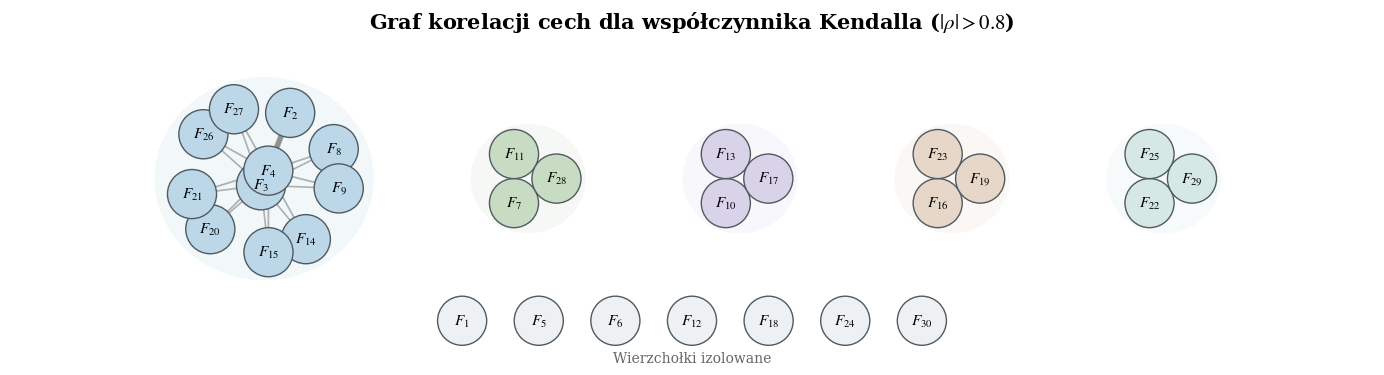

In [19]:
G, corr, pos = draw_corr_graph_horizontal(
    df,
    method="kendall",
    threshold=0.8,
    style="scientific",
    figsize=(14, 5.8),
    output_png="corr_kendall_scientific.png",
    output_pdf="corr_kendall_scientific.pdf"
)

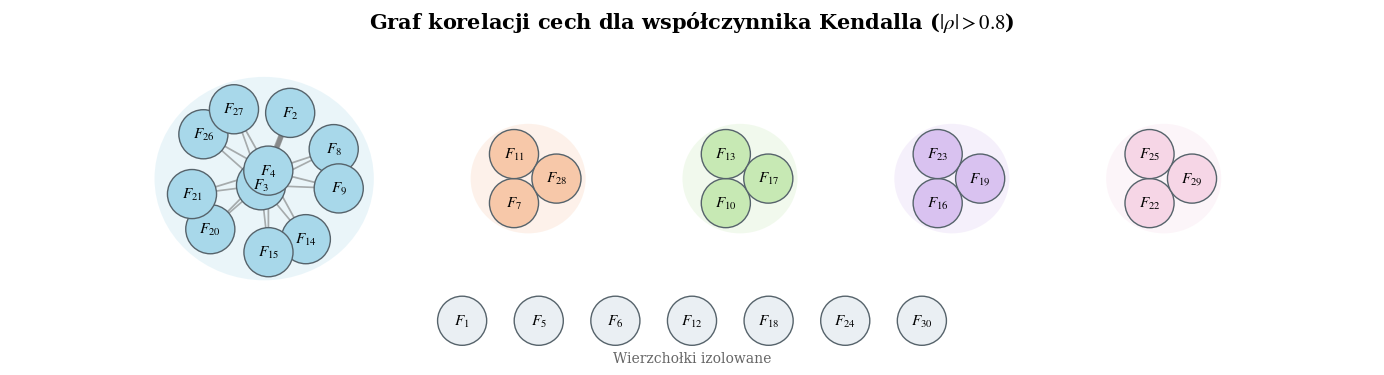

In [20]:
G, corr, pos = draw_corr_graph_horizontal(
    df,
    method="kendall",
    threshold=0.8,
    style="pastel",
    figsize=(14, 5.8),
    output_png="corr_kendall_pastel.png",
    output_pdf="corr_kendall_pastel.pdf"
)

In [24]:
import re
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from matplotlib.lines import Line2D
from matplotlib.patches import Ellipse

# ============================================================
# USTAWIENIA
# ============================================================

THRESHOLD = 0.8

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "stix",
    "font.size": 11,
})


# ============================================================
# FUNKCJE POMOCNICZE
# ============================================================

def feature_num(name):
    m = re.search(r"(\d+)$", str(name))
    return int(m.group(1)) if m else 10**9


def pretty_label(name):
    n = feature_num(name)
    if n < 10**9:
        return rf"$F_{{{n}}}$"
    return str(name)


def build_graph(corr, columns, threshold=0.8):
    G = nx.Graph()
    G.add_nodes_from(columns)

    for i in range(len(columns)):
        for j in range(i + 1, len(columns)):
            w = float(corr.iloc[i, j])
            if w > threshold:
                G.add_edge(columns[i], columns[j], weight=w)

    return G


def component_layout_single_panel(G, seed=7):
    """
    Układ podobny do tego z Twojego screena:
    - największa grupa mniej więcej pośrodku,
    - pozostałe grupy wokół,
    - izolowane cechy osobno.
    """
    comps = [sorted(list(c), key=feature_num) for c in nx.connected_components(G)]
    nontrivial = [c for c in comps if len(c) > 1]
    isolates = [c[0] for c in comps if len(c) == 1]

    nontrivial.sort(key=lambda c: (-len(c), feature_num(c[0])))
    isolates = sorted(isolates, key=feature_num)

    pos = {}

    # --------------------------------------------------------
    # Główna grupa w centrum
    # --------------------------------------------------------
    if nontrivial:
        main = nontrivial[0]
        H = G.subgraph(main)

        if len(main) <= 3:
            local = nx.circular_layout(H, scale=0.22)
        else:
            local = nx.spring_layout(H, seed=seed, k=0.45)

            arr = np.array([local[n] for n in H.nodes()])
            arr = arr - arr.mean(axis=0)
            max_norm = np.max(np.linalg.norm(arr, axis=1))
            if max_norm > 0:
                arr = arr / max_norm * 0.24
            local = {node: arr[i] for i, node in enumerate(H.nodes())}

        for n in H.nodes():
            pos[n] = np.array(local[n])

    # --------------------------------------------------------
    # Pozostałe grupy wokół środka
    # --------------------------------------------------------
    satellites = nontrivial[1:]
    n_sat = len(satellites)

    if n_sat > 0:
        angles = np.linspace(0, 2*np.pi, n_sat, endpoint=False) + 0.25
        R = 0.78

        for idx, (comp, angle) in enumerate(zip(satellites, angles)):
            cx = R * np.cos(angle)
            cy = R * np.sin(angle)

            H = G.subgraph(comp)

            if len(comp) == 2:
                local = {
                    comp[0]: np.array([-0.07, 0.00]),
                    comp[1]: np.array([+0.07, 0.00]),
                }

            elif len(comp) == 3:
                local = nx.circular_layout(H, scale=0.10)

            else:
                local = nx.spring_layout(H, seed=seed + idx + 1, k=0.30)
                arr = np.array([local[n] for n in H.nodes()])
                arr = arr - arr.mean(axis=0)
                max_norm = np.max(np.linalg.norm(arr, axis=1))
                if max_norm > 0:
                    arr = arr / max_norm * 0.13
                local = {node: arr[i] for i, node in enumerate(H.nodes())}

            for n in H.nodes():
                pos[n] = np.array([cx, cy]) + np.array(local[n])

    # --------------------------------------------------------
    # Izolowane na zewnętrznym pierścieniu
    # --------------------------------------------------------
    if isolates:
        n_iso = len(isolates)
        angles = np.linspace(0, 2*np.pi, n_iso, endpoint=False) + 0.15
        R_iso = 1.22

        for n, angle in zip(isolates, angles):
            pos[n] = np.array([R_iso * np.cos(angle), R_iso * np.sin(angle)])

    return pos, nontrivial, isolates


def component_ellipse_params(nodes, pos, pad_x=0.18, pad_y=0.14):
    pts = np.array([pos[n] for n in nodes])
    cx, cy = pts.mean(axis=0)

    xmin, ymin = pts.min(axis=0)
    xmax, ymax = pts.max(axis=0)

    width = max(0.30, (xmax - xmin) + 2 * pad_x)
    height = max(0.30, (ymax - ymin) + 2 * pad_y)

    return cx, cy, width, height


def draw_single_graph(
    ax,
    G,
    title,
    threshold=0.8,
    style="scientific",
    seed=7
):
    pos, nontrivial, isolates = component_layout_single_panel(G, seed=seed)

    # --------------------------------------------------------
    # STYLE
    # --------------------------------------------------------
    if style == "pastel":
        palette = [
            "#A8D8EA",
            "#F7C8A9",
            "#C7E9B4",
            "#D9C2F0",
            "#F6D6E6",
            "#F9E79F",
            "#AED9CE",
        ]
        edge_color = "#757575"
        node_edge = "#536169"
        iso_color = "#EAEFF3"
        halo_alpha = 0.24
    else:
        palette = [
            "#BCD7E8",
            "#C8DCC3",
            "#D9D3EA",
            "#E7D7C9",
            "#D6E8E4",
            "#E7E3BF",
            "#D7DDE8",
        ]
        edge_color = "#777777"
        node_edge = "#505A61"
        iso_color = "#EEF1F4"
        halo_alpha = 0.18

    # --------------------------------------------------------
    # Overlaye grup
    # --------------------------------------------------------
    for i, comp in enumerate(nontrivial):
        color = palette[i % len(palette)]
        cx, cy, w, h = component_ellipse_params(comp, pos)

        halo = Ellipse(
            (cx, cy),
            width=w,
            height=h,
            facecolor=color,
            edgecolor="none",
            alpha=halo_alpha,
            zorder=0
        )
        ax.add_patch(halo)

    # --------------------------------------------------------
    # Krawędzie
    # --------------------------------------------------------
    edges = list(G.edges(data=True))
    if edges:
        widths = [
            1.0 + 3.2 * ((d["weight"] - threshold) / (1.0 - threshold))
            for _, _, d in edges
        ]

        nx.draw_networkx_edges(
            G,
            pos,
            ax=ax,
            width=widths,
            edge_color=edge_color,
            alpha=0.55
        )

    # --------------------------------------------------------
    # Kolory węzłów
    # --------------------------------------------------------
    node_colors = {}

    for i, comp in enumerate(nontrivial):
        color = palette[i % len(palette)]
        for n in comp:
            node_colors[n] = color

    for n in isolates:
        node_colors[n] = iso_color

    nx.draw_networkx_nodes(
        G,
        pos,
        ax=ax,
        node_size=950,
        node_color=[node_colors[n] for n in G.nodes()],
        edgecolors=node_edge,
        linewidths=0.9
    )

    # --------------------------------------------------------
    # Etykiety
    # --------------------------------------------------------
    labels = {n: pretty_label(n) for n in G.nodes()}
    nx.draw_networkx_labels(
        G,
        pos,
        labels=labels,
        ax=ax,
        font_size=10
    )

    ax.set_title(title, fontsize=12, pad=8)
    ax.set_axis_off()
    ax.set_aspect("equal")
    ax.margins(0.10)


# ============================================================
# GŁÓWNA FUNKCJA: 3 PANELE + PIONOWE KRESKI
# ============================================================

def draw_corr_graphs_three_panels(
    df,
    threshold=0.8,
    style="scientific",   # "scientific" albo "pastel"
    output_png="feature_correlation_graphs_pretty.png",
    output_pdf="feature_correlation_graphs_pretty.pdf"
):
    corr_methods = {
        "Pearson": df.corr().abs(),
        "Spearman": df.corr(method="spearman").abs(),
        "Kendall": df.corr(method="kendall").abs(),
    }

    columns = list(df.columns)

    graphs = {
        name: build_graph(corr, columns, threshold=threshold)
        for name, corr in corr_methods.items()
    }

    fig, axes = plt.subplots(1, 3, figsize=(16, 5.4))
    fig.patch.set_facecolor("white")

    for ax, (idx, (name, G)) in zip(axes, enumerate(graphs.items())):
        draw_single_graph(
            ax,
            G,
            title=name,
            threshold=threshold,
            style=style,
            seed=7 + idx
        )

   
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    fig.subplots_adjust(wspace=0.12)

    # pionowe linie oddzielające panele
    for x in [1/3, 2/3]:
        fig.add_artist(
            Line2D(
                [x, x],
                [0.12, 0.86],
                transform=fig.transFigure,
                color="0.78",
                linewidth=1.2
            )
        )

    plt.savefig(output_png, dpi=300, bbox_inches="tight")
    plt.savefig(output_pdf, bbox_inches="tight")
    plt.show()

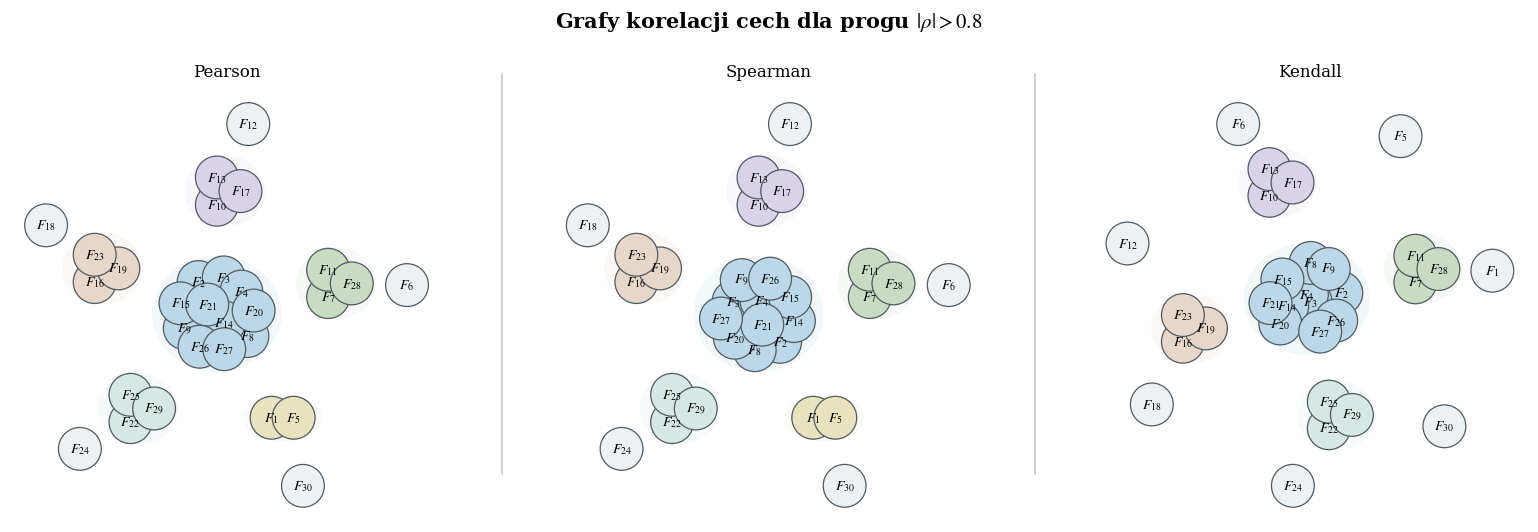

In [22]:
draw_corr_graphs_three_panels(
    df,
    threshold=0.8,
    style="scientific",
    output_png="corr_graphs_scientific.png",
    output_pdf="corr_graphs_scientific.pdf"
)

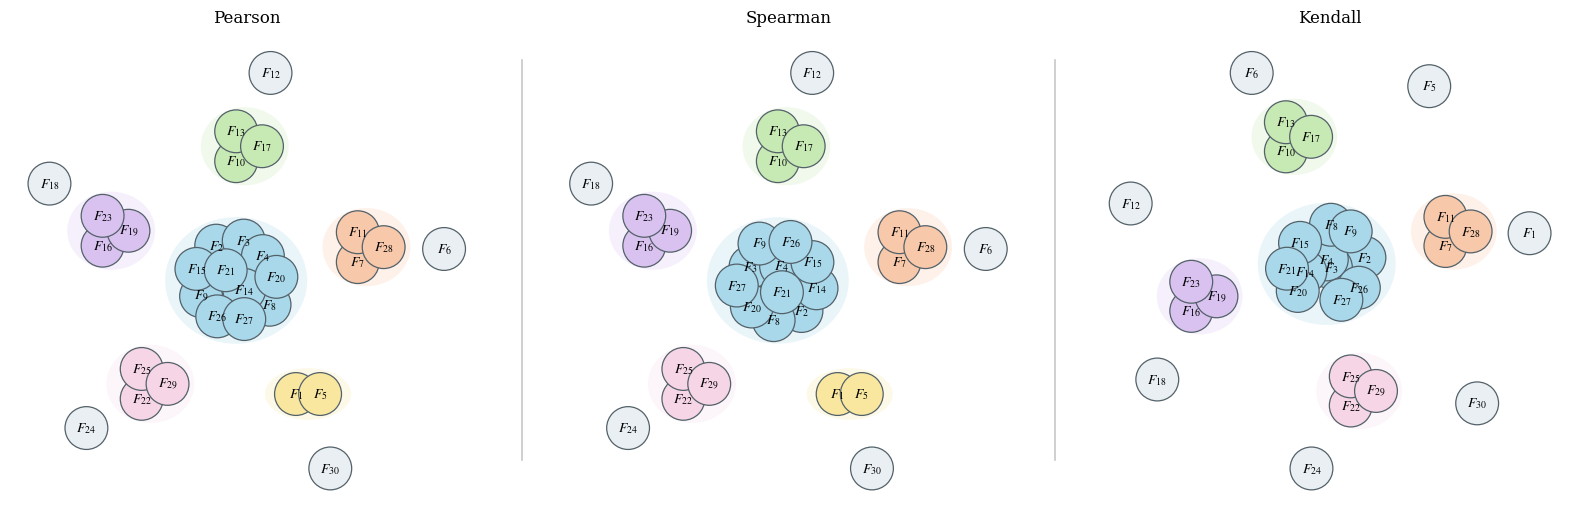

In [25]:
draw_corr_graphs_three_panels(
    df,
    threshold=0.8,
    style="pastel",
    output_png="corr_graphs_pastel.png",
    output_pdf="corr_graphs_pastel.pdf"
)